In [ ]:
#dataset_review.ipynb 

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
from config import TRAIN_PATH, TEST_PATH

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv(TRAIN_PATH, names=columns)
test_df = pd.read_csv(TEST_PATH, names=columns)

train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [19]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.info()

Train shape: (125973, 43)
Test shape: (22544, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_comp

Feature Types

Categorical Features:
- protocol_type
- service
- flag

Numerical Features:
- duration, src_bytes, dst_bytes, count, etc.

Target Label:
- label (normal vs attack)

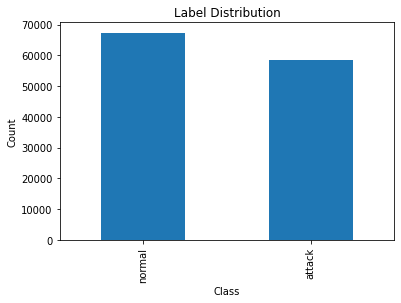

In [20]:
train_df["label"] = train_df["label"].apply(lambda x: "normal" if x == "normal" else "attack")

train_df["label"].value_counts().plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [21]:
for col in ["protocol_type", "service", "flag"]:
    print(f"\n{col} unique values:")
    print(train_df[col].unique())


protocol_type unique values:
['tcp' 'udp' 'icmp']

service unique values:
['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

flag unique values:
['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']


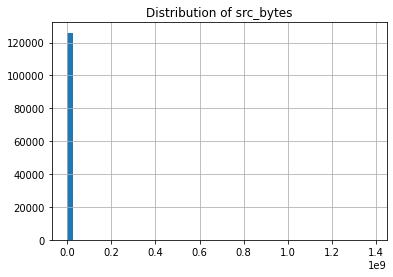

In [22]:
train_df["src_bytes"].hist(bins=50)
plt.title("Distribution of src_bytes")
plt.show()

In [23]:
from preprocess import load_and_preprocess

X_train, y_train, X_test, y_test = load_and_preprocess()

In [24]:
print("Processed Train Shape:", X_train.shape)
print("Processed Test Shape:", X_test.shape)

Processed Train Shape: (125973, 122)
Processed Test Shape: (22544, 122)


Preprocessing Steps
1. Removed "difficulty" column  
2. Converted labels:
   - normal → 0
   - attack → 1  
3. One-hot encoded categorical features  
4. Normalized numerical features using MinMaxScaler  
5. Combined all features into final input vectors  

Final dataset is ready for deep learning models.

In [25]:
print("Sample processed feature vector:")
print(X_train[0])

print("Label:", y_train[0])

Sample processed feature vector:
[0.00000000e+00 3.55806412e-07 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.91389432e-03
 3.91389432e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 0.00000000e+00 0.00000000e+00
 5.88235294e-01 9.80392157e-02 1.70000000e-01 3.00000000e-02
 1.70000000e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 5.00000000e-02 0.00000000e+00 0.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 0.00000000e+00 0.0000

In [26]:
print("Final feature dimension:", X_train.shape[1])

Final feature dimension: 122


After preprocessing, categorical features are expanded using one-hot encoding, increasing the total feature dimension.

In [27]:
print("Original features:", len(columns) - 2)  # excluding label & difficulty
print("Processed features:", X_train.shape[1])

Original features: 41
Processed features: 122
